
#### **Parte Práctica**: 

Vamos usar los dataset winequality-white y winequality-red. 



In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

1. **Exploración Inicial**:
   - Visualiza las primeras filas del dataset.
   - Realiza la matriz de correlacion para ver la relación entre las variables numéricas.

In [58]:
# Visualización del dataset y matriz de correlación.
vinos = pd.read_csv('winequality.csv', sep=';')
vinos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,r
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,r
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,r
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,r
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,r


In [59]:
vinos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


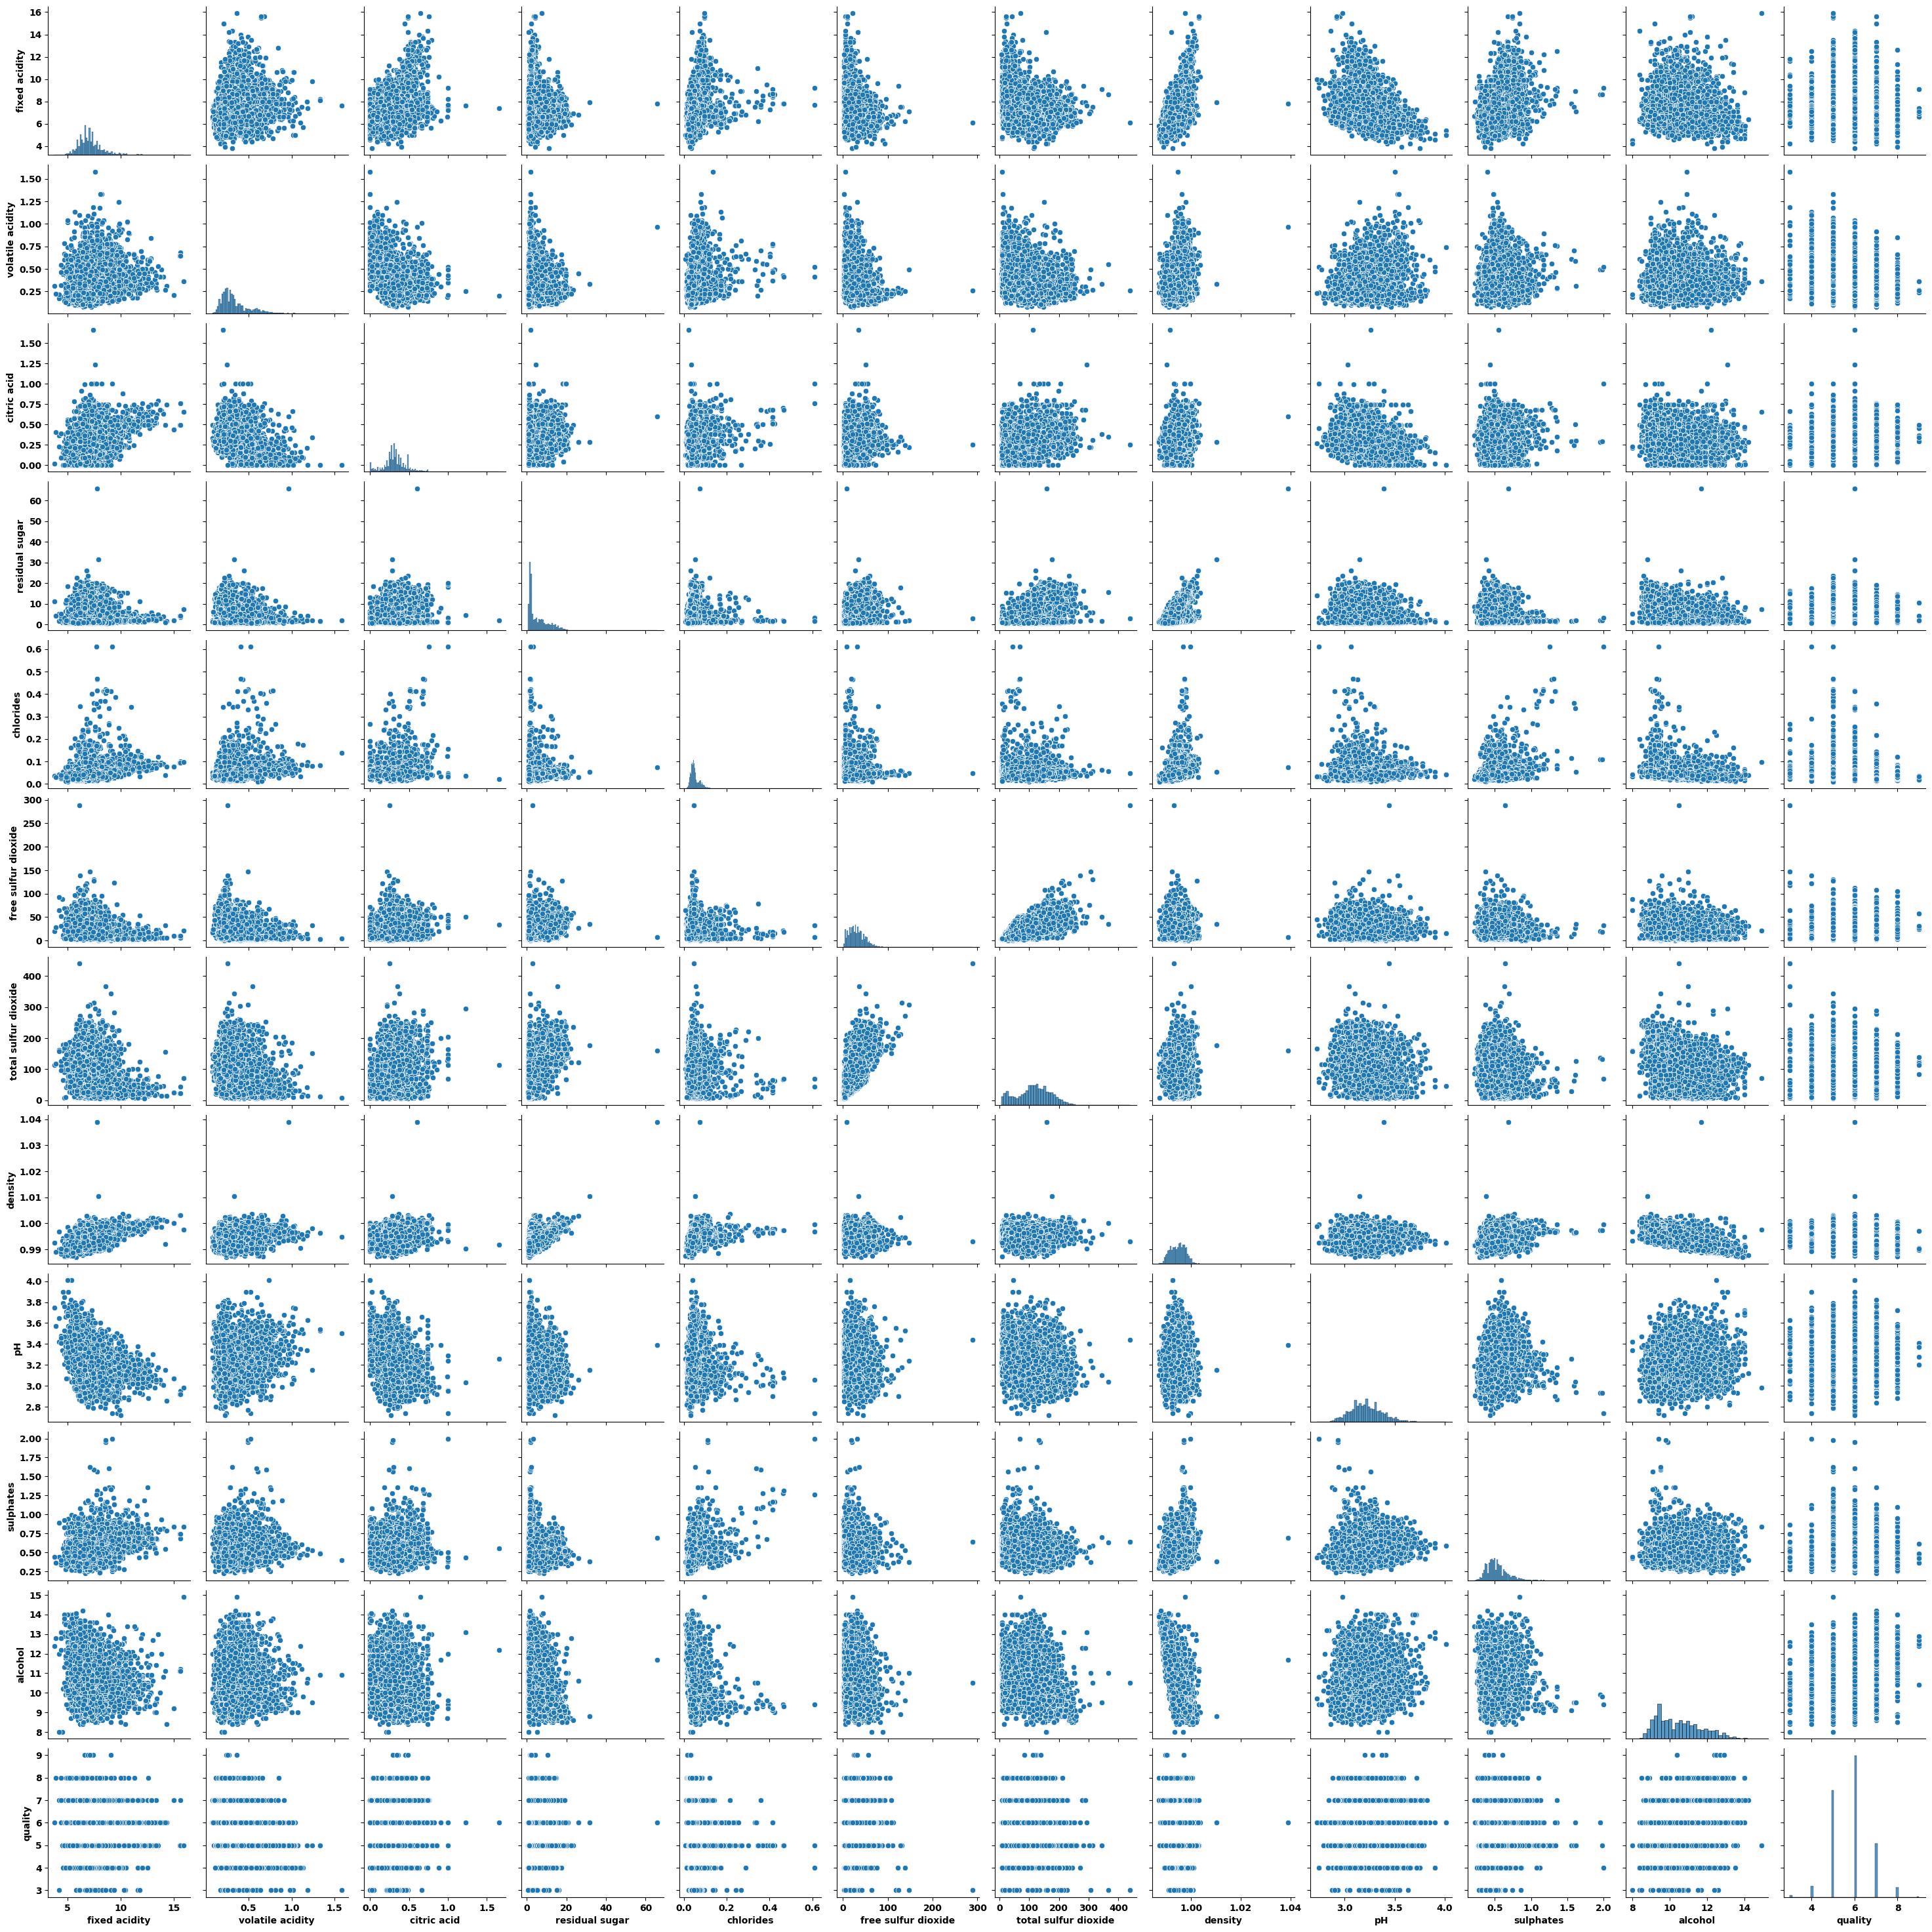

In [4]:
sns.pairplot(vinos)

**Mapa de Calor Correlaciones - Todo el Dataset**

Text(0.5, 1.0, 'Heatmap Filtrado (corr >= 0.5) - Correlación de Pearson')

<Figure size 1000x1000 with 0 Axes>

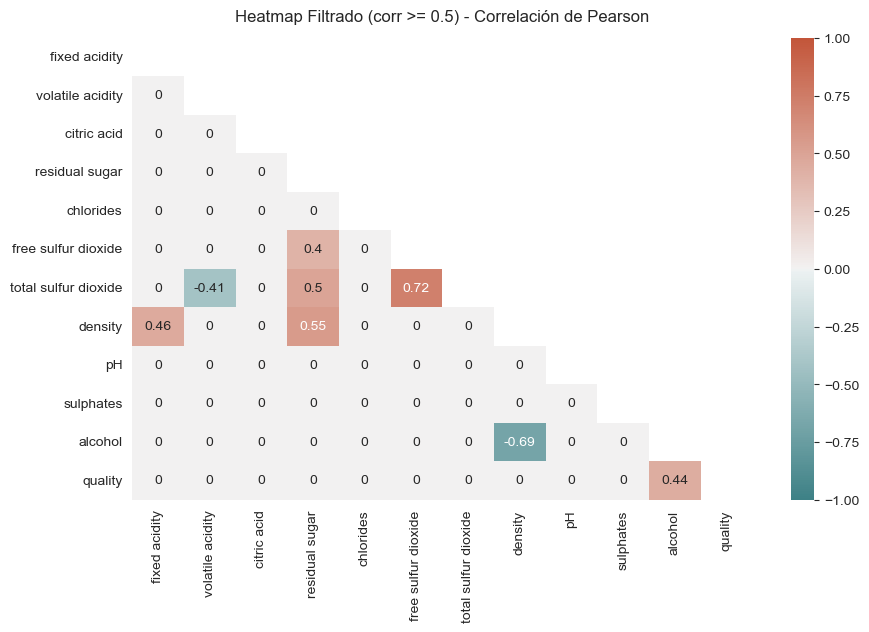

In [4]:
sns.set_style('white')
plt.figure(figsize=(10,10))

sns.set_style("white")
corr = vinos.corr(numeric_only=True)

corr[np.abs(corr)<0.4] = 0
plt.figure(figsize=(10, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(200,20,as_cmap=True)

heatmap = sns.heatmap(corr, vmin=-1, vmax=1, mask=mask, annot=True, cmap=cmap)
heatmap.set_title('Heatmap Filtrado (corr >= 0.5) - Correlación de Pearson', fontdict={'fontsize':12}, pad=12)

**Mapa de Calor Correlaciones - Vinos Rojos**

Text(0.5, 1.0, 'Heatmap Filtrado (corr >= 0.3) - Correlación de Pearson')

<Figure size 1000x1000 with 0 Axes>

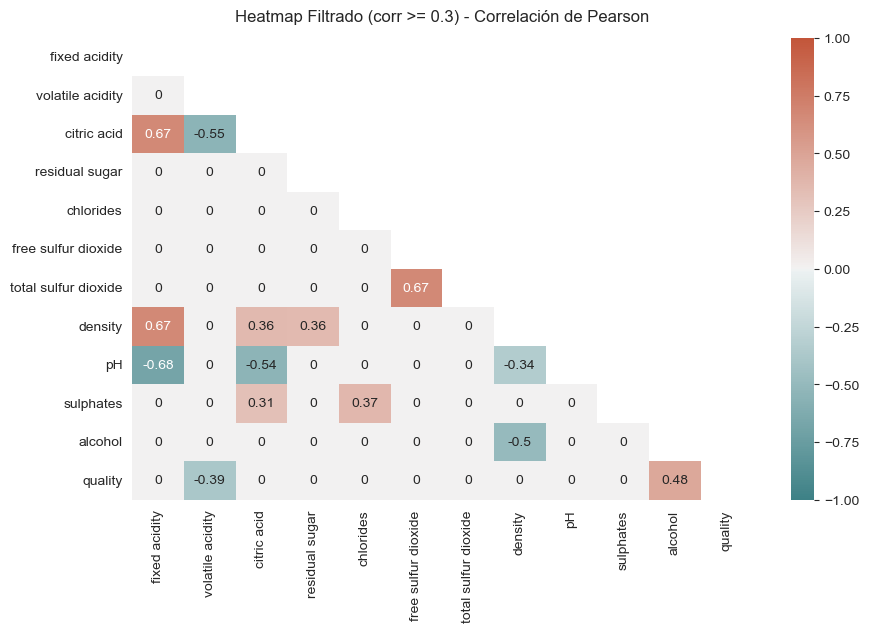

In [6]:
vinos_rojos = vinos[vinos.wine=='r']

sns.set_style('white')
plt.figure(figsize=(10,10))

sns.set_style("white")
corr = vinos_rojos.corr(numeric_only=True)

corr[np.abs(corr)<0.3] = 0
plt.figure(figsize=(10, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(200,20,as_cmap=True)

heatmap = sns.heatmap(corr, vmin=-1, vmax=1, mask=mask, annot=True, cmap=cmap)
heatmap.set_title('Heatmap Filtrado (corr >= 0.3) - Correlación de Pearson', fontdict={'fontsize':12}, pad=12)

**Mapa de Calor Correlaciones - Vinos Blancos**

Text(0.5, 1.0, 'Heatmap Filtrado (corr >= 0.3) - Correlación de Pearson')

<Figure size 1000x1000 with 0 Axes>

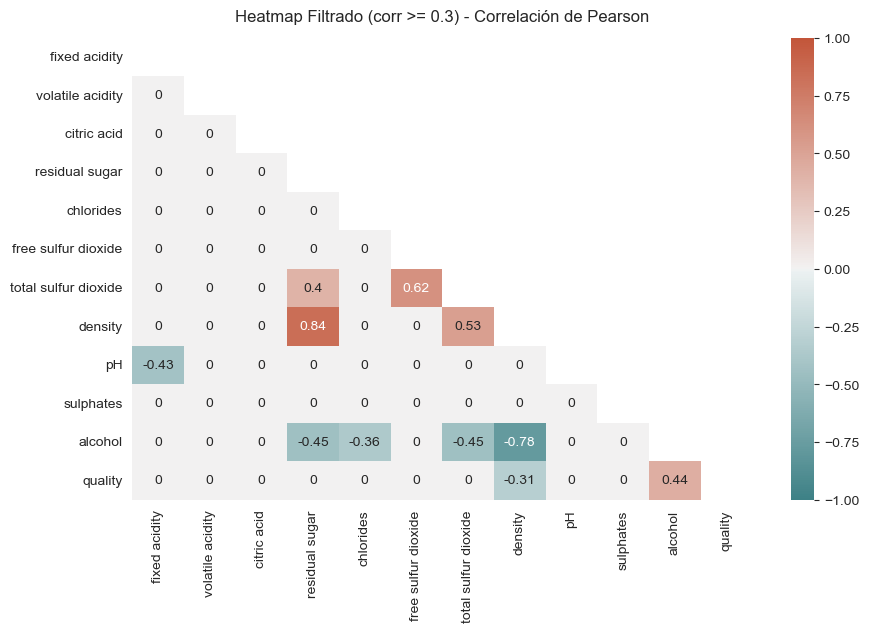

In [7]:
vinos_blancos = vinos[vinos.wine=='w']

sns.set_style('white')
plt.figure(figsize=(10,10))

sns.set_style("white")
corr = vinos_blancos.corr(numeric_only=True)

corr[np.abs(corr)<0.3] = 0
plt.figure(figsize=(10, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(200,20,as_cmap=True)

heatmap = sns.heatmap(corr, vmin=-1, vmax=1, mask=mask, annot=True, cmap=cmap)
heatmap.set_title('Heatmap Filtrado (corr >= 0.3) - Correlación de Pearson', fontdict={'fontsize':12}, pad=12)


2. **Modelos Anidados**:
   - Crear un modelo de regresion lineal simple para el dataset de winequality que explique la 'variable density' de solo los vinos rojos.
   - Crear un modelo de regresion multiple para el dataset de winequality que explique la varible 'residual sugar' de solo los vinos blancos.


In [8]:
vinos_rojos.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'wine'],
      dtype='object')

Modelo de regresión lineal simple para el dataset de winequality que explique la 'variable density' de solo los vinos rojos

In [9]:
# Creación del modelo básico con para el dataset winequality.

# Implementa tu respuesta en esta celda
import statsmodels.formula.api as smf

# Modelo RLS
modelo_redwine = smf.ols('density ~ Q("fixed acidity")', data=vinos_rojos).fit()
print(modelo_redwine.summary())


                            OLS Regression Results                            
Dep. Variable:                density   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     1287.
Date:                Fri, 03 Nov 2023   Prob (F-statistic):          3.07e-207
Time:                        20:52:13   Log-Likelihood:                 8234.1
No. Observations:                1599   AIC:                        -1.646e+04
Df Residuals:                    1597   BIC:                        -1.645e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9907      0

Modelo de regresión multiple para el dataset de winequality que explique la variable 'residual sugar' de solo los vinos blancos.

In [10]:
vinos_blancos.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'wine'],
      dtype='object')

In [11]:
# Creación del modelo de regresion multiple para el dataset winequality.

# Modelo RLM
modelo_wwine = smf.ols('Q("residual sugar") ~ alcohol + density + Q("total sulfur dioxide")', data=vinos_blancos).fit()
print(modelo_wwine.summary())


                             OLS Regression Results                            
Dep. Variable:     Q("residual sugar")   R-squared:                       0.811
Model:                             OLS   Adj. R-squared:                  0.811
Method:                  Least Squares   F-statistic:                     6996.
Date:                 Fri, 03 Nov 2023   Prob (F-statistic):               0.00
Time:                         20:52:16   Log-Likelihood:                -10824.
No. Observations:                 4898   AIC:                         2.166e+04
Df Residuals:                     4894   BIC:                         2.168e+04
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept   


3. **Pruebas F Anidadas**:
   - Realiza una prueba F anidada entre los dos modelos.


Modelo de Regresión Lineal Múltiple:

density ~ fixed acidity + alcohol

In [12]:
# Creación del modelo básico con para el dataset winequality.

# Implementa tu respuesta en esta celda
import statsmodels.formula.api as smf

# Modelo RLS
modelo_redwine_RLM = smf.ols('density ~ Q("fixed acidity") + alcohol', data=vinos_rojos).fit()
print(modelo_redwine_RLM.summary())


                            OLS Regression Results                            
Dep. Variable:                density   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     1509.
Date:                Fri, 03 Nov 2023   Prob (F-statistic):               0.00
Time:                        20:52:19   Log-Likelihood:                 8610.2
No. Observations:                1599   AIC:                        -1.721e+04
Df Residuals:                    1596   BIC:                        -1.720e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9994      0

In [13]:
# Prueba F anidada entre los dos modelos.

import statsmodels.api as sm


# Compare the models using an ANOVA test
anova_results = sm.stats.anova_lm(modelo_redwine, modelo_redwine_RLM)

print(anova_results)

   df_resid       ssr  df_diff   ss_diff           F         Pr(>F)
0    1597.0  0.003152      0.0       NaN         NaN            NaN
1    1596.0  0.001969      1.0  0.001183  958.758847  2.935884e-165


Modelo de Regresión Lineal Simple:

Residual Sugar ~ density

In [14]:
# Modelo RLM
modelo_wwine_RLS = smf.ols('Q("residual sugar") ~ density', data=vinos_blancos).fit()
print(modelo_wwine_RLS.summary())

                             OLS Regression Results                            
Dep. Variable:     Q("residual sugar")   R-squared:                       0.704
Model:                             OLS   Adj. R-squared:                  0.704
Method:                  Least Squares   F-statistic:                 1.164e+04
Date:                 Fri, 03 Nov 2023   Prob (F-statistic):               0.00
Time:                         20:52:21   Log-Likelihood:                -11922.
No. Observations:                 4898   AIC:                         2.385e+04
Df Residuals:                     4896   BIC:                         2.386e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1407.8522     13.110   -107.38

In [15]:
# Prueba F anidada entre los dos modelos.

import statsmodels.api as sm


# Compare the models using an ANOVA test
anova_results = sm.stats.anova_lm(modelo_wwine_RLS, modelo_wwine)

print(anova_results)

   df_resid           ssr  df_diff       ss_diff            F  Pr(>F)
0    4896.0  37306.855965      0.0           NaN          NaN     NaN
1    4894.0  23820.901197      2.0  13485.954769  1385.343529     0.0


4. **Variables Categóricas**:
   - Añade la variable extra al modelo propuesto de winequality del modelo de regresión simple y verificar si el se mejora el ajuste.

In [24]:
vinos_rojos.loc[:, 'quality']=vinos_rojos['quality'].astype('category')

In [25]:
vinos_rojos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         1599 non-null   float64 
 1   volatile acidity      1599 non-null   float64 
 2   citric acid           1599 non-null   float64 
 3   residual sugar        1599 non-null   float64 
 4   chlorides             1599 non-null   float64 
 5   free sulfur dioxide   1599 non-null   float64 
 6   total sulfur dioxide  1599 non-null   float64 
 7   density               1599 non-null   float64 
 8   pH                    1599 non-null   float64 
 9   sulphates             1599 non-null   float64 
 10  alcohol               1599 non-null   float64 
 11  quality               1599 non-null   category
 12  wine                  1599 non-null   object  
dtypes: category(1), float64(11), object(1)
memory usage: 164.2+ KB


In [26]:
# Añadiendo la variable categórica sex al modelo mediante codificación dummy.

# Modelo RLS
modelo_redwine_cat = smf.ols('density ~ Q("fixed acidity") + quality', data=vinos_rojos).fit()
print(modelo_redwine_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                density   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     292.8
Date:                Fri, 03 Nov 2023   Prob (F-statistic):          7.44e-253
Time:                        20:57:50   Log-Likelihood:                 8356.0
No. Observations:                1599   AIC:                        -1.670e+04
Df Residuals:                    1592   BIC:                        -1.666e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9911      0

5. **Interacciones**:
   - Añade una interacción entre para el modelo de winequality que explica la variable 'residual sugar'.

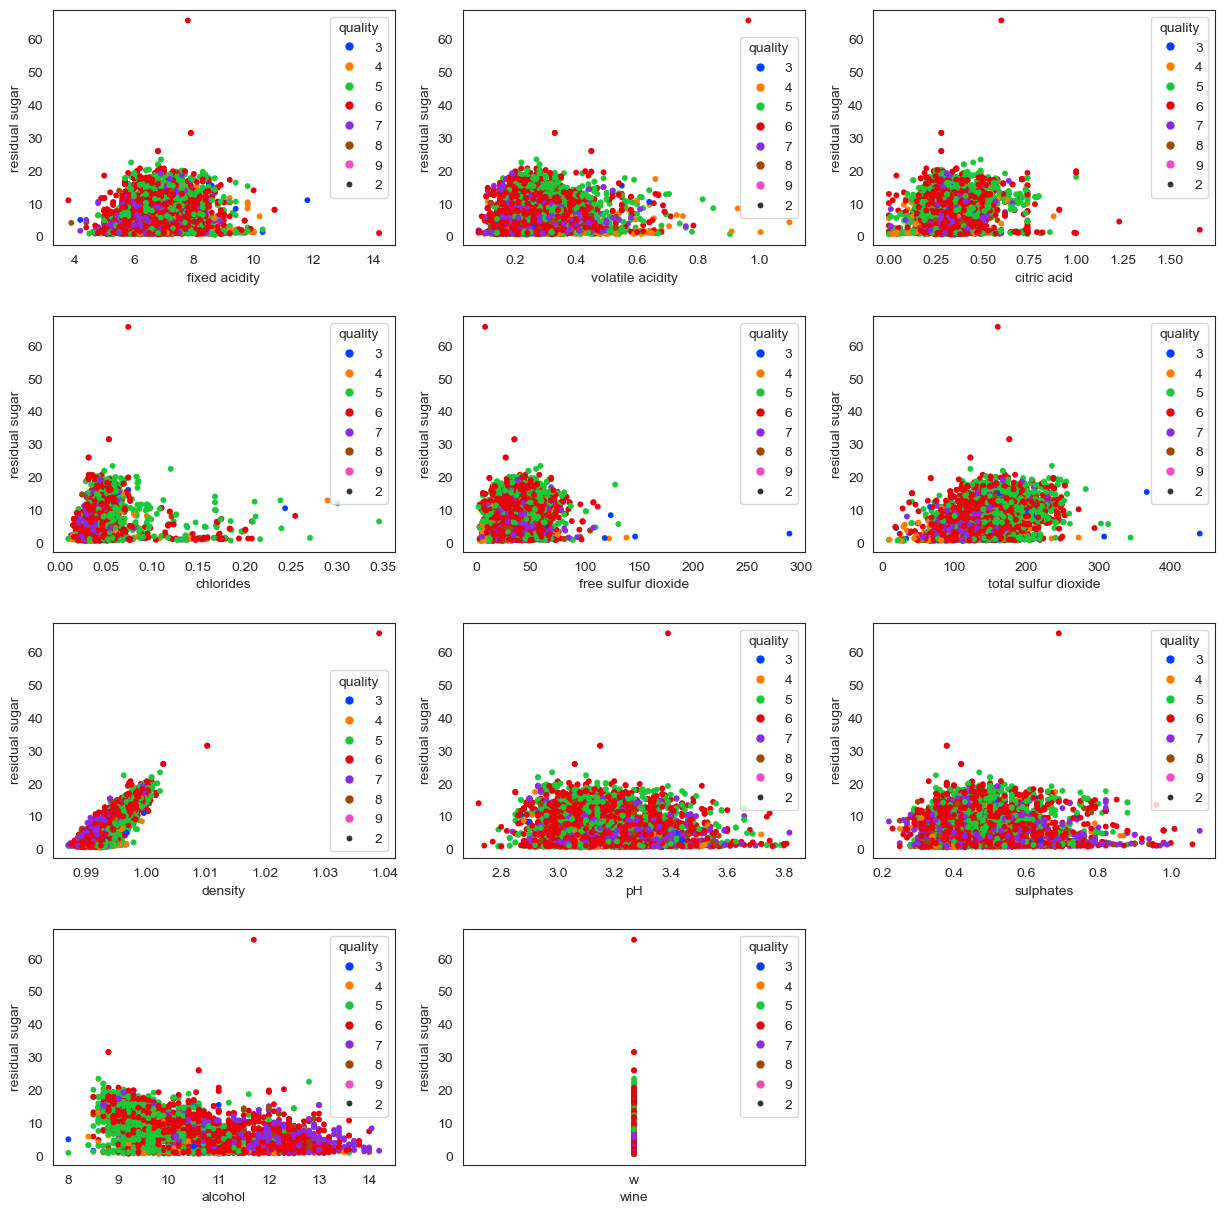

In [27]:
# Se crea una lista con las variables categóricas y numéricas
var_num = ['fixed acidity', 'volatile acidity', 'citric acid', 
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'wine']

plt.figure(figsize=(15, 15))
plt.subplots_adjust(hspace=0.3)
# plt.suptitle("Relación entre Variables Independientes y el Precio de la Propiedad", fontsize=14, y=0.92)


# sns.set(rc={"figure.figsize":(15, 15)})
sns.set_style("white")
# fig, axs = plt.subplots(4, 3)
# Se itera sobre las variables para crear cada figura.
for i, var in enumerate(var_num):
    ax = plt.subplot(4, 3, i + 1)
    sns.scatterplot(data=vinos_blancos, x=var, y='residual sugar', 
                        hue='quality', ax=ax, size=2, linewidth=0, palette="bright")
# fig.tight_layout()
plt.show()

In [77]:
vinos_blancos.loc[:,'quality']=vinos_blancos['quality'].astype('category')

In [33]:
# Añadiendo una interacción entre total_bill y size al modelo.

# Modelo RLM
modelo_wwine_int = smf.ols('Q("residual sugar") ~ alcohol + density + Q("total sulfur dioxide") + quality*density', data=vinos_blancos).fit()
print(modelo_wwine_int.summary())


                             OLS Regression Results                            
Dep. Variable:     Q("residual sugar")   R-squared:                       0.822
Model:                             OLS   Adj. R-squared:                  0.822
Method:                  Least Squares   F-statistic:                     1504.
Date:                 Fri, 03 Nov 2023   Prob (F-statistic):               0.00
Time:                         20:58:52   Log-Likelihood:                -10675.
No. Observations:                 4898   AIC:                         2.138e+04
Df Residuals:                     4882   BIC:                         2.149e+04
Df Model:                           15                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept   


6. **Pruebas de Bondad de Ajuste**:
   - Compara R-squared, R-square adj y el MSE entre los cuatro modelos.


In [34]:
# Comparación del R-squared, R-square sdj y el MSE (Error Cuadrático Medio) entre los cuatro modelos.

rmse_modelo_redwine = np.sqrt(np.mean(modelo_redwine.resid**2))
rmse_modelo_redwine_RLM = np.sqrt(np.mean(modelo_redwine_RLM.resid**2))
rmse_modelo_redwine_cat = np.sqrt(np.mean(modelo_redwine_cat.resid**2))



rmse_wwine_RLS = np.sqrt(np.mean(modelo_wwine_RLS.resid**2))
rmse_modelo_wwine = np.sqrt(np.mean(modelo_wwine.resid**2))
rmse_modelo_wwine_int = np.sqrt(np.mean(modelo_redwine_cat.resid**2))

print('Modelos Vino Rojo')
print('RMSE')
print('Modelo {density ~ fixed_acidity}: \t\t\t\t', rmse_modelo_redwine)
print('Modelo 1 {density ~ fixed_acidity + alcohol}:\t\t\t', rmse_modelo_redwine_RLM)
print('Modelo 2 {density ~ fixed_acidity + quality}:\t\t\t', rmse_modelo_redwine_cat, '\n')

print('R^2')
print('Modelo {density ~ fixed_acidity}: \t\t\t\t', modelo_redwine.rsquared)
print('Modelo 1 {density ~ fixed_acidity + alcohol}:\t\t\t', modelo_redwine_RLM.rsquared)
print('Modelo 2 {density ~ fixed_acidity + quality}:\t\t\t', modelo_redwine_cat.rsquared, '\n')

print('R^2 Ajustado')
print('Modelo {density ~ fixed_acidity}: \t\t\t\t', modelo_redwine.rsquared_adj)
print('Modelo 1 {density ~ fixed_acidity + alcohol}:\t\t\t', modelo_redwine_RLM.rsquared_adj)
print('Modelo 2 {density ~ fixed_acidity + quality}::\t\t\t', modelo_redwine_cat.rsquared_adj, '\n')


print('Modelos Vino Blanco')
print('RMSE')
print('Modelo {residual_sugar ~ density}: \t\t\t\t\t\t\t\t\t', rmse_wwine_RLS)
print('Modelo 1 {residual_sugar ~ alcohol + density + Q("total sulfur dioxide")}:\t\t\t\t', rmse_modelo_wwine)
print('Modelo 2 {residual sugar ~ alcohol + density + total sulfur dioxide + quality*density}:\t\t\t', rmse_modelo_wwine_int,'\n')

print('R^2')
print('Modelo {residual_sugar ~ density}: \t\t\t\t\t\t\t\t\t', modelo_wwine_RLS.rsquared)
print('Modelo 1 {residual_sugar ~ alcohol + density + Q("total sulfur dioxide")}:\t\t\t\t', modelo_wwine.rsquared)
print('Modelo 2 {residual sugar ~ alcohol + density + total sulfur dioxide + quality*density}:\t\t\t', modelo_wwine_int.rsquared,'\n')

print('R^2 Ajustado')
print('Modelo {residual_sugar ~ density}: \t\t\t\t\t\t\t\t\t', modelo_wwine_RLS.rsquared_adj)
print('Modelo 1 {residual_sugar ~ alcohol + density + Q("total sulfur dioxide")}:\t\t\t\t', modelo_wwine.rsquared_adj)
print('Modelo 2 {residual sugar ~ alcohol + density + total sulfur dioxide + quality*density}:\t\t\t', modelo_wwine_int.rsquared_adj)

Modelos Vino Rojo
RMSE
Modelo {density ~ fixed_acidity}: 				 0.001403961492774221
Modelo 1 {density ~ fixed_acidity + alcohol}:			 0.0011096772537926443
Modelo 2 {density ~ fixed_acidity + quality}:			 0.001300876270144112 

R^2
Modelo {density ~ fixed_acidity}: 				 0.44628718450749405
Modelo 1 {density ~ fixed_acidity + alcohol}:			 0.6540864690461357
Modelo 2 {density ~ fixed_acidity + quality}:			 0.5246142429257401 

R^2 Ajustado
Modelo {density ~ fixed_acidity}: 				 0.44594046389666586
Modelo 1 {density ~ fixed_acidity + alcohol}:			 0.6536529934434365
Modelo 2 {density ~ fixed_acidity + quality}::			 0.5228225880623949 

Modelos Vino Blanco
RMSE
Modelo {residual_sugar ~ density}: 									 2.759846545241957
Modelo 1 {residual_sugar ~ alcohol + density + Q("total sulfur dioxide")}:				 2.205310287924614
Modelo 2 {residual sugar ~ alcohol + density + total sulfur dioxide + quality*density}:			 0.001300876270144112 

R^2
Modelo {residual_sugar ~ density}: 									 0.703864712455


7. **Análisis de Residuos**:
   - Grafica los residuos frente a los valores ajustados para el último modelo.
   - Realiza un QQ-Plot para verificar la normalidad de los residuos.


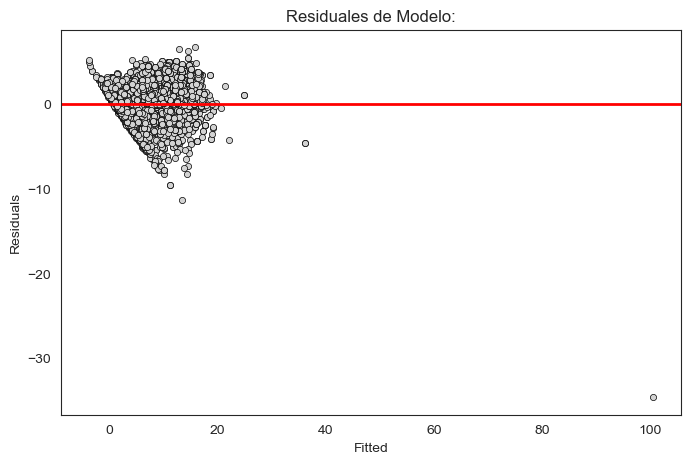

In [35]:
# Gráfica de los residuos frente a los valores ajustados para el último modelo.

# Implementa tu respuesta en esta celda

# Residuals plot
plt.figure(figsize=(8,5))
plt.scatter(modelo_wwine_int.fittedvalues, modelo_wwine_int.resid, 
            color='lightgray', edgecolors='k', linewidths=0.5, s=20)
plt.axhline(0, color='red', lw=2)
plt.title('Residuales de Modelo:')
plt.xlabel('Fitted')
plt.ylabel('Residuals')
plt.show()



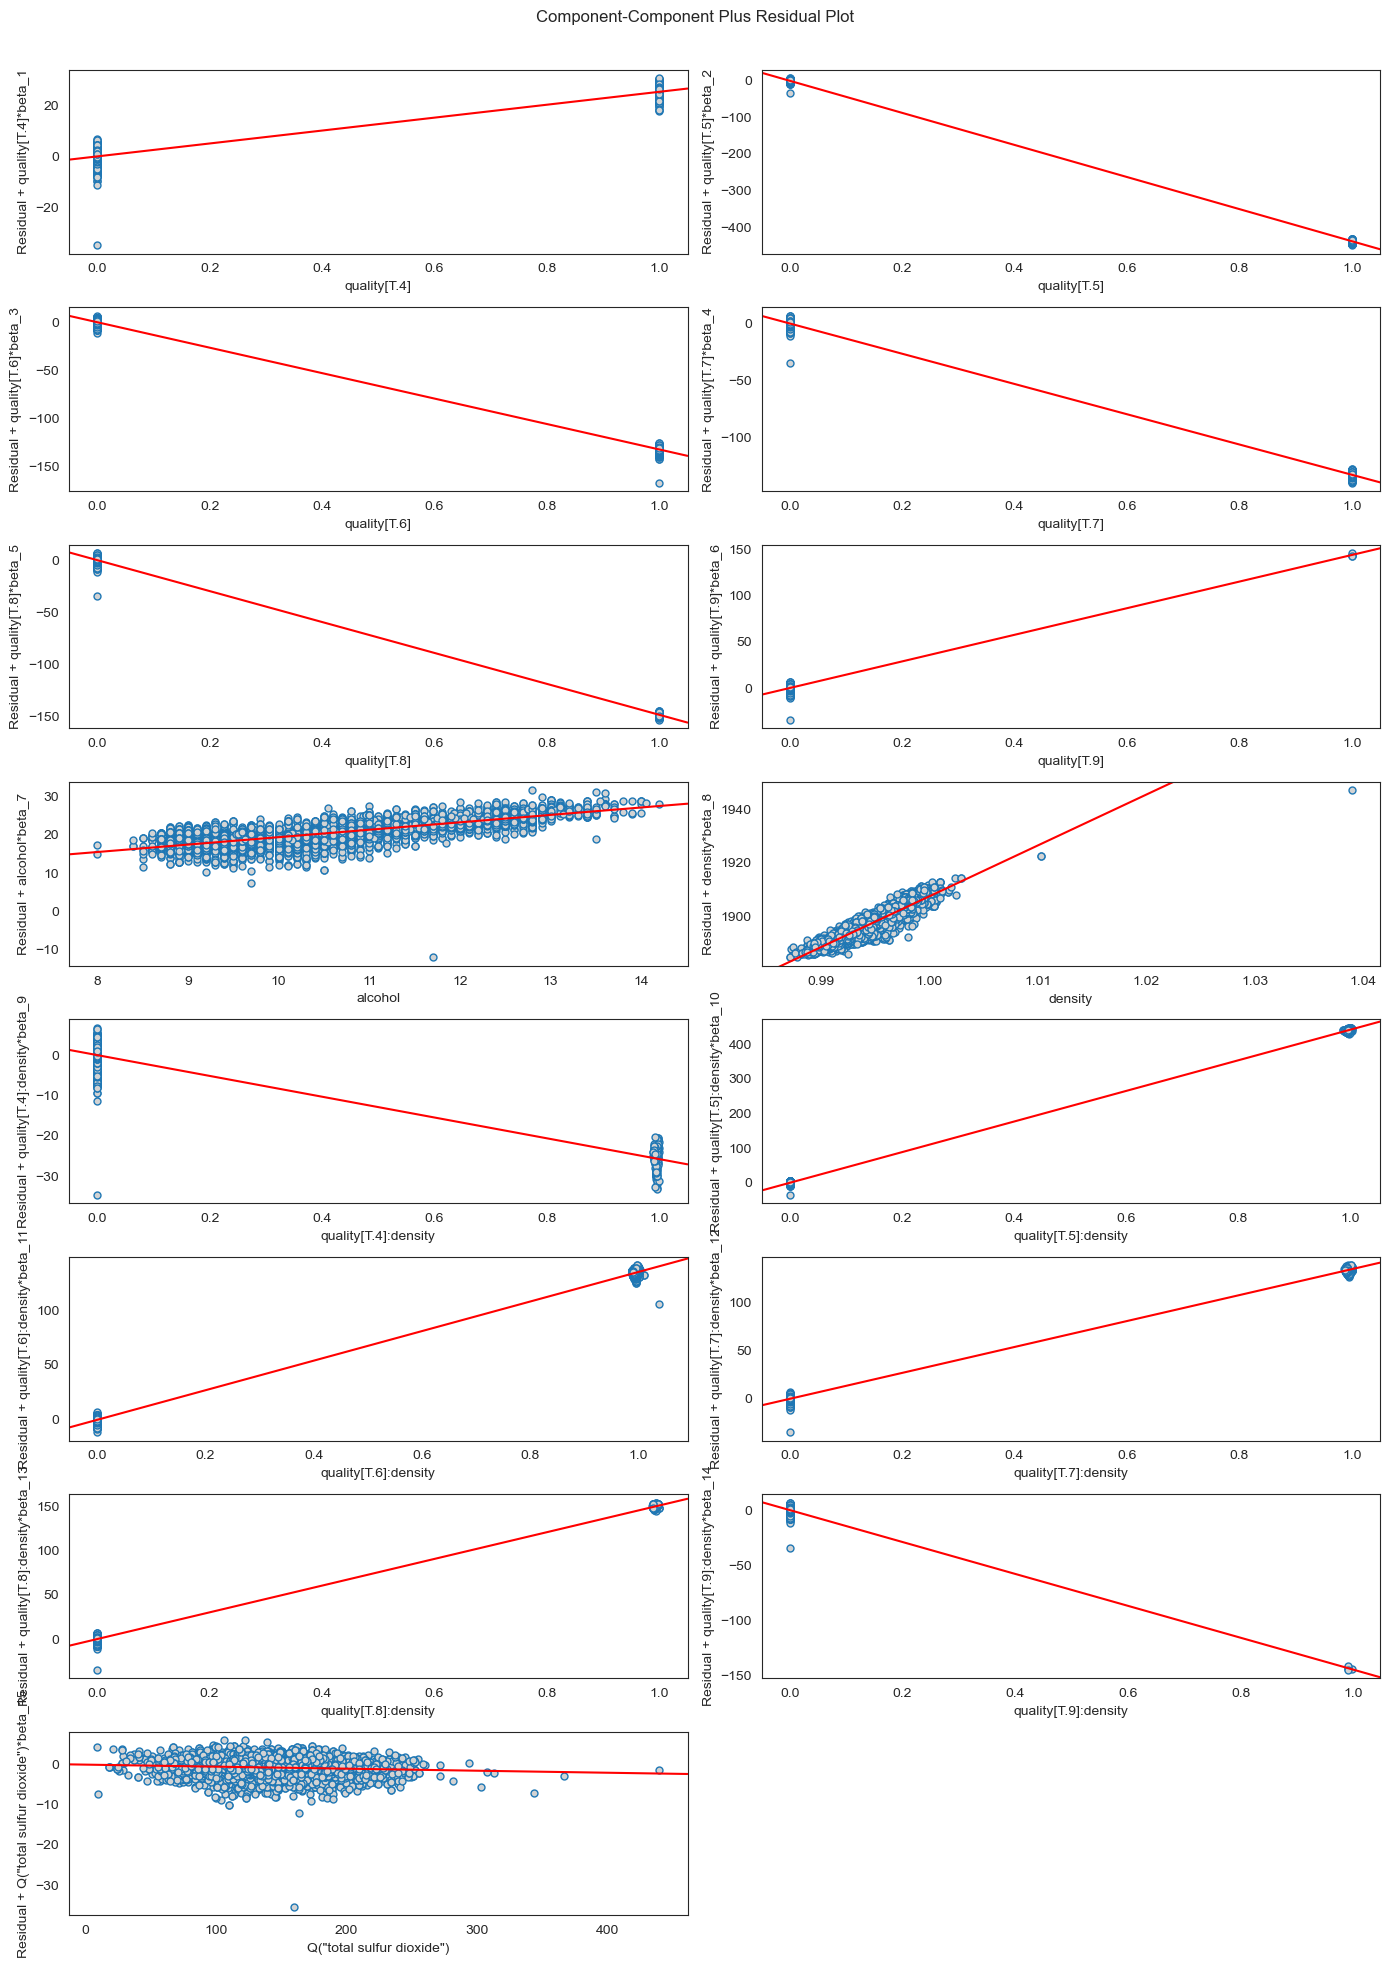

In [36]:
fig = plt.figure(figsize=(14, 20))
sm.graphics.plot_ccpr_grid(modelo_wwine_int, fig=fig)

all_axes = fig.get_axes()
for ax in all_axes:
    ax.get_lines()[0].set_markerfacecolor('lightgrey')
    ax.get_lines()[0].set_markersize(5)
    ax.get_lines()[1].set_color('red')
plt.show()

Se realiza el diagnóstico empleando las siguientes funciones:

In [60]:
# Función de Diagnóstico
import statsmodels
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tools.tools import maybe_unwrap_results
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from typing import Type

style_talk = 'seaborn-v0_8-talk'    #refer to plt.style.available

class LinearRegDiagnostic():
    """
    Diagnostic plots to identify potential problems in a linear regression fit.
    Mainly,
        a. non-linearity of data
        b. Correlation of error terms
        c. non-constant variance
        d. outliers
        e. high-leverage points
        f. collinearity

    Authors:
        Prajwal Kafle (p33ajkafle@gmail.com, where 3 = r)
        Does not come with any sort of warranty.
        Please test the code one your end before using.

        Matt Spinelli (m3spinelli@gmail.com, where 3 = r)
        (1) Fixed incorrect annotation of the top most extreme residuals in
            the Residuals vs Fitted and, especially, the Normal Q-Q plots.
        (2) Changed Residuals vs Leverage plot to match closer the y-axis
            range shown in the equivalent plot in the R package ggfortify.
        (3) Added horizontal line at y=0 in Residuals vs Leverage plot to
            match the plots in R package ggfortify and base R.
        (4) Added option for placing a vertical guideline on the Residuals
            vs Leverage plot using the rule of thumb of h = 2p/n to denote
            high leverage (high_leverage_threshold=True).
        (5) Added two more ways to compute the Cook's Distance (D) threshold:
            * 'baseR': D > 1 and D > 0.5 (default)
            * 'convention': D > 4/n
            * 'dof': D > 4 / (n - k - 1)
        (6) Fixed class name to conform to Pascal casing convention
        (7) Fixed Residuals vs Leverage legend to work with loc='best'
    """

    def __init__(self,
                 results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper]) -> None:
        """
        For a linear regression model, generates following diagnostic plots:

        a. residual
        b. qq
        c. scale location and
        d. leverage

        and a table

        e. vif

        Args:
            results (Type[statsmodels.regression.linear_model.RegressionResultsWrapper]):
                must be instance of statsmodels.regression.linear_model object

        Raises:
            TypeError: if instance does not belong to above object

        Example:
        >>> import numpy as np
        >>> import pandas as pd
        >>> import statsmodels.formula.api as smf
        >>> x = np.linspace(-np.pi, np.pi, 100)
        >>> y = 3*x + 8 + np.random.normal(0,1, 100)
        >>> df = pd.DataFrame({'x':x, 'y':y})
        >>> res = smf.ols(formula= "y ~ x", data=df).fit()
        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls(plot_context="seaborn-v0_8-paper")

        In case you do not need all plots you can also independently make an individual plot/table
        in following ways

        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls.residual_plot()
        >>> cls.qq_plot()
        >>> cls.scale_location_plot()
        >>> cls.leverage_plot()
        >>> cls.vif_table()
        """

        if isinstance(results, statsmodels.regression.linear_model.RegressionResultsWrapper) is False:
            raise TypeError("result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object")

        self.results = maybe_unwrap_results(results)

        self.y_true = self.results.model.endog
        self.y_predict = self.results.fittedvalues
        self.xvar = self.results.model.exog
        self.xvar_names = self.results.model.exog_names

        self.residual = np.array(self.results.resid)
        influence = self.results.get_influence()
        self.residual_norm = influence.resid_studentized_internal
        self.leverage = influence.hat_matrix_diag
        self.cooks_distance = influence.cooks_distance[0]
        self.nparams = len(self.results.params)
        self.nresids = len(self.residual_norm)

    def __call__(self, plot_context='seaborn-v0_8-paper', **kwargs):
        # print(plt.style.available)
        with plt.style.context(plot_context):
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
            self.residual_plot(ax=ax[0,0])
            self.qq_plot(ax=ax[0,1])
            self.scale_location_plot(ax=ax[1,0])
            self.leverage_plot(
                ax=ax[1,1],
                high_leverage_threshold = kwargs.get('high_leverage_threshold'),
                cooks_threshold = kwargs.get('cooks_threshold'))
            plt.show()

        return self.vif_table(), fig, ax,

    def residual_plot(self, ax=None):
        """
        Residual vs Fitted Plot

        Graphical tool to identify non-linearity.
        (Roughly) Horizontal red line is an indicator that the residual has a linear pattern
        """
        if ax is None:
            fig, ax = plt.subplots()

        sns.residplot(
            x=self.y_predict,
            y=self.residual,
            lowess=True,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        residual_abs = np.abs(self.residual)
        abs_resid = np.flip(np.argsort(residual_abs), 0)
        abs_resid_top_3 = abs_resid[:3]
        for i in abs_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], self.residual[i]),
                color='C3')

        ax.set_title('Residuals vs Fitted', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel('Residuals')
        return ax

    def qq_plot(self, ax=None):
        """
        Standarized Residual vs Theoretical Quantile plot

        Used to visually check if residuals are normally distributed.
        Points spread along the diagonal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        QQ = ProbPlot(self.residual_norm)
        fig = QQ.qqplot(line='45', alpha=0.5, lw=1, ax=ax)

        # annotations
        abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
        abs_norm_resid_top_3 = abs_norm_resid[:3]
        for i, x, y in self.__qq_top_resid(QQ.theoretical_quantiles, abs_norm_resid_top_3):
            ax.annotate(
                i,
                xy=(x, y),
                ha='right',
                color='C3')

        ax.set_title('Normal Q-Q', fontweight="bold")
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Standardized Residuals')
        return ax

    def scale_location_plot(self, ax=None):
        """
        Sqrt(Standarized Residual) vs Fitted values plot

        Used to check homoscedasticity of the residuals.
        Horizontal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))

        ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5);
        sns.regplot(
            x=self.y_predict,
            y=residual_norm_abs_sqrt,
            scatter=False, ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
        abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
        for i in abs_sq_norm_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], residual_norm_abs_sqrt[i]),
                color='C3')

        ax.set_title('Scale-Location', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$');
        return ax

    def leverage_plot(self, ax=None, high_leverage_threshold=False, cooks_threshold='baseR'):
        """
        Residual vs Leverage plot

        Points falling outside Cook's distance curves are considered observation that can sway the fit
        aka are influential.
        Good to have none outside the curves.
        """
        if ax is None:
            fig, ax = plt.subplots()

        ax.scatter(
            self.leverage,
            self.residual_norm,
            alpha=0.5);

        sns.regplot(
            x=self.leverage,
            y=self.residual_norm,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(
                i,
                xy=(self.leverage[i], self.residual_norm[i]),
                color = 'C3')

        factors = []
        if cooks_threshold == 'baseR' or cooks_threshold is None:
            factors = [1, 0.5]
        elif cooks_threshold == 'convention':
            factors = [4/self.nresids]
        elif cooks_threshold == 'dof':
            factors = [4/ (self.nresids - self.nparams)]
        else:
            raise ValueError("threshold_method must be one of the following: 'convention', 'dof', or 'baseR' (default)")
        for i, factor in enumerate(factors):
            label = "Cook's distance" if i == 0 else None
            xtemp, ytemp = self.__cooks_dist_line(factor)
            ax.plot(xtemp, ytemp, label=label, lw=1.25, ls='--', color='red')
            ax.plot(xtemp, np.negative(ytemp), lw=1.25, ls='--', color='red')

        if high_leverage_threshold:
            high_leverage = 2 * self.nparams / self.nresids
            if max(self.leverage) > high_leverage:
                ax.axvline(high_leverage, label='High leverage', ls='-.', color='purple', lw=1)

        ax.axhline(0, ls='dotted', color='black', lw=1.25)
        ax.set_xlim(0, max(self.leverage)+0.01)
        ax.set_ylim(min(self.residual_norm)-0.1, max(self.residual_norm)+0.1)
        ax.set_title('Residuals vs Leverage', fontweight="bold")
        ax.set_xlabel('Leverage')
        ax.set_ylabel('Standardized Residuals')
        plt.legend(loc='best')
        return ax

    def vif_table(self):
        """
        VIF table

        VIF, the variance inflation factor, is a measure of multicollinearity.
        VIF > 5 for a variable indicates that it is highly collinear with the
        other input variables.
        """
        vif_df = pd.DataFrame()
        vif_df["Features"] = self.xvar_names
        vif_df["VIF Factor"] = [variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])]

        return (vif_df
                .sort_values("VIF Factor")
                .round(2))


    def __cooks_dist_line(self, factor):
        """
        Helper function for plotting Cook's distance curves
        """
        p = self.nparams
        formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
        x = np.linspace(0.001, max(self.leverage), 50)
        y = formula(x)
        return x, y


    def __qq_top_resid(self, quantiles, top_residual_indices):
        """
        Helper generator function yielding the index and coordinates
        """
        offset = 0
        quant_index = 0
        previous_is_negative = None
        for resid_index in top_residual_indices:
            y = self.residual_norm[resid_index]
            is_negative = y < 0
            if previous_is_negative == None or previous_is_negative == is_negative:
                offset += 1
            else:
                quant_index -= offset
            x = quantiles[quant_index] if is_negative else np.flip(quantiles, 0)[quant_index]
            quant_index += 1
            previous_is_negative = is_negative
            yield resid_index, x, y

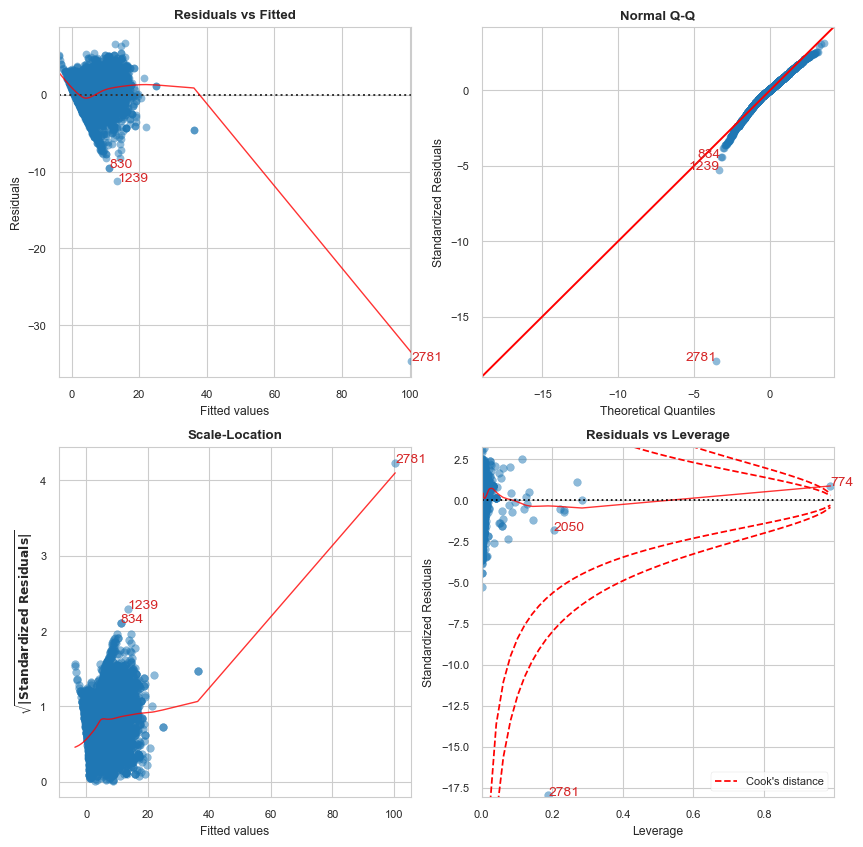

In [61]:
cls = LinearRegDiagnostic(modelo_wwine_int)
vif, fig, ax = cls()

In [41]:
# Realización del QQ-Plot para verificar la normalidad de los residuos.

# Obtener los residuos del modelo

import statsmodels.api as sm 
from scipy import stats
# Se crea la siguiente función para diagnosticar la Normalidad de los residuos
def diagn_norm_resid(modelo):

    """
    La función genera el histograma y el gráfico QQ de los residuos del modelo ingresado, e implementa las pruebas de normalidad
    de Shapiro Wilk y Kolmogorov-Smirnov, devolviendo los resultados en cada caso.
        
    """
    # Histograma
    sns.reset_orig()
    sns.set_style("whitegrid")

    fig, axes = plt.subplots(1,2, figsize=(15,5))

    sns.histplot(modelo.resid,  
                color = 'darkred', edgecolor = 'white',
                #  alpha = 0.6, bins = 100, 
                kde=True, ax=axes[0]
                ).set_title('Histograma de Residuos')

    
    # QQ-Plot
    fig=sm.qqplot(modelo.resid, line="s",
                    markeredgecolor='darkred', markerfacecolor='white',
                    markersize=6, mew=0.8, ax=axes[1])
    plt.title('QQplot - Distribución Normal')
    plt.gca().get_lines()[1].set_color('k')
    plt.gca().get_lines()[1].set_linewidth(2)
    plt.show()

    # Pruebas de Normalidad de los Residuos
    print('*'*23, 'Pruebas de Normalidad' ,'*'*23, '\n')
    print("Prueba de Shapiro-Wilk:", stats.shapiro(modelo.resid), '\n')
    print("Prueba de Kolmogorov - Smirnov:", stats.kstest(modelo.resid, 'norm'))
   


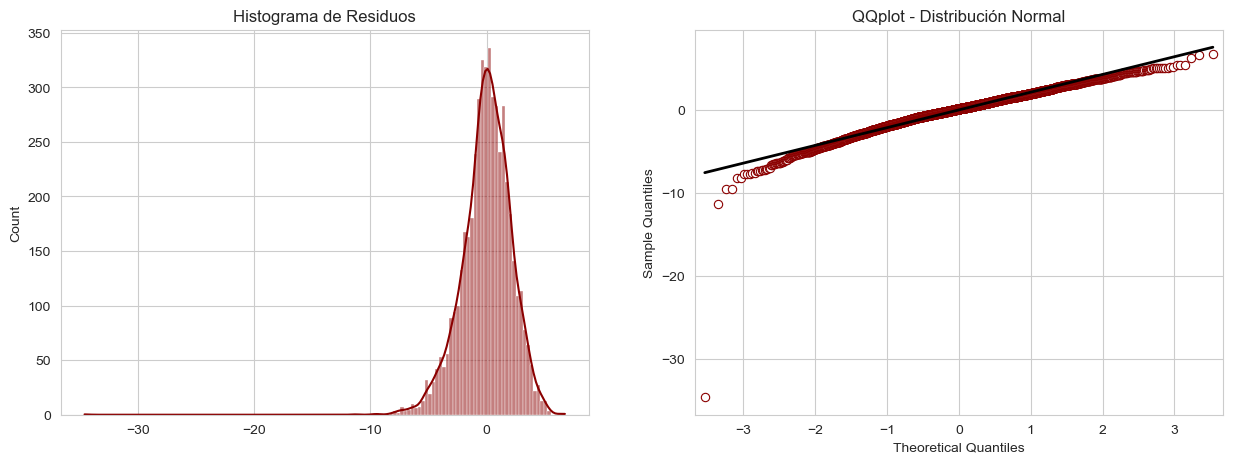

*********************** Pruebas de Normalidad *********************** 

Prueba de Shapiro-Wilk: ShapiroResult(statistic=0.9555038213729858, pvalue=2.982611540908623e-36) 

Prueba de Kolmogorov - Smirnov: KstestResult(statistic=0.17528024965712108, pvalue=4.379587785506055e-132, statistic_location=1.3311893343252326, statistic_sign=-1)


In [42]:
diagn_norm_resid(modelo_wwine_int)


8. **Metodo de selección de variables**:
   - Realice de nuevo el modelo de regresión multiple para ambos casos usando el metodo de busqueda exahustiva.
   - Realice de nuevo el modelo de regresión multiple para ambos casos usando el metodo de busqueda hacia adelante.
   - Realice de nuevo el modelo de regresión multiple para ambos casos usando el metodo de busqueda hacia atras.
   
   


In [64]:
#import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
from sklearn.base import clone
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

class SMWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, sm_model=None):
        self.sm_model = sm_model
        
    def fit(self, X, y):
        if self.sm_model is None:
            self.sm_model_ = sm.OLS(y, sm.add_constant(X)).fit()
        else:
            # Clone the model to make sure the original isn't fit again
            cloned_model = clone(self.sm_model)
            self.sm_model_ = cloned_model.fit(sm.add_constant(X), y)
        return self
    
    def predict(self, X):
        return self.sm_model_.predict(sm.add_constant(X))
    
    def get_params(self, deep=True):
        return {'sm_model': self.sm_model}

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def aic_scorer(self, estimator, X, y):
        return -1 * estimator.sm_model_.aic  # we multiply by -1 because SequentialFeatureSelector tries to maximize the score

    def bic_scorer(self, estimator, X, y):
        return -1 * estimator.sm_model_.bic  # we multiply by -1 because SequentialFeatureSelector tries to maximize the score


def select_features_using_criterion(X, y, criterion='aic', forward=True,floating=False):
    sm_model = SMWrapper()

    if criterion == 'aic':
        scorer = sm_model.aic_scorer
    elif criterion == 'bic':
        scorer = sm_model.bic_scorer
    else:
        raise ValueError("Invalid criterion. Choose 'aic' or 'bic'")

    sfs = SFS(sm_model, 
              k_features=(1, X.shape[1]), 
              forward=forward, 
              floating=False, 
              scoring=scorer, 
              cv=0)
    sfs = sfs.fit(X, y)
    return sfs

**Modelo Vinos Rojos**

Método de Búsqueda Exhaustiva


In [65]:
vinos_rojos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         1599 non-null   float64 
 1   volatile acidity      1599 non-null   float64 
 2   citric acid           1599 non-null   float64 
 3   residual sugar        1599 non-null   float64 
 4   chlorides             1599 non-null   float64 
 5   free sulfur dioxide   1599 non-null   float64 
 6   total sulfur dioxide  1599 non-null   float64 
 7   density               1599 non-null   float64 
 8   pH                    1599 non-null   float64 
 9   sulphates             1599 non-null   float64 
 10  alcohol               1599 non-null   float64 
 11  quality               1599 non-null   category
 12  wine                  1599 non-null   object  
dtypes: category(1), float64(11), object(1)
memory usage: 164.2+ KB


In [66]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
import matplotlib.pyplot as plt

X = vinos_rojos.drop(['density', 'wine'], axis=1)
y = vinos_rojos['density']

# Define the model
sm_model = SMWrapper()

efs = EFS(sm_model, 
          min_features=1,
          max_features=X.shape[1], 
          scoring='neg_mean_squared_error',
          print_progress=True,
          cv=0)


efs = efs.fit(X, y)
print('Best accuracy score: %.2f' % efs.best_score_)
print('Best subset (indices):', efs.best_idx_)
print('Best subset (corresponding names):', efs.best_feature_names_)

Features: 2047/2047

Best accuracy score: -0.00
Best subset (indices): (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
Best subset (corresponding names): ('fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'quality')


**Busqueda hacia Adelante**

In [70]:
X = vinos_rojos.drop(['density', 'wine'], axis=1)
y = vinos_rojos['density']

# Select features using BIC
sfs_result_bic_f = select_features_using_criterion(X, y, criterion='bic', forward=True)

# Features selected based on BIC
selected_features_bic_f = X.columns[list(sfs_result_bic_f.k_feature_idx_)]
print(f"Selected Features based on BIC: {selected_features_bic_f}")

# Adjust a full model using only the selected features
X_selected = X[selected_features_bic_f]
redwine_forw_bic = sm.OLS(y, sm.add_constant(X_selected)).fit()

# Print the model summary
print(redwine_forw_bic.summary())

Selected Features based on BIC: Index(['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:                density   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     1201.
Date:                Sat, 04 Nov 2023   Prob (F-statistic):               0.00
Time:                        10:52:58   Log-Likelihood:                 9231.3
No. Observations:                1599   AIC:                        -1.845e+04
Df Residuals:                    1591   BIC:                        -1.840e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err     

**Busqueda hacia Atrás**

In [71]:
X = vinos_rojos.drop(['density', 'wine'], axis=1)
y = vinos_rojos['density']

# Select features using BIC
sfs_result_bic_f = select_features_using_criterion(X, y, criterion='bic', forward=False)

# Features selected based on BIC
selected_features_bic_f = X.columns[list(sfs_result_bic_f.k_feature_idx_)]
print(f"Selected Features based on BIC: {selected_features_bic_f}")

# Adjust a full model using only the selected features
X_selected = X[selected_features_bic_f]
redwine_back_bic = sm.OLS(y, sm.add_constant(X_selected)).fit()

# Print the model summary
print(redwine_back_bic.summary())

Selected Features based on BIC: Index(['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:                density   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     1201.
Date:                Sat, 04 Nov 2023   Prob (F-statistic):               0.00
Time:                        10:53:40   Log-Likelihood:                 9231.3
No. Observations:                1599   AIC:                        -1.845e+04
Df Residuals:                    1591   BIC:                        -1.840e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err     

**Modelo Vinos Blancos**

Método de Búsqueda Exhaustiva


In [78]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
import matplotlib.pyplot as plt

X = vinos_blancos.drop(['residual sugar', 'wine'], axis=1)
y = vinos_blancos['residual sugar']

# Define the model
sm_model = SMWrapper()

efs = EFS(sm_model, 
          min_features=1,
          max_features=X.shape[1], 
          scoring='neg_mean_squared_error',
          print_progress=True,
          cv=0)


efs = efs.fit(X, y)
print('Best accuracy score: %.2f' % efs.best_score_)
print('Best subset (indices):', efs.best_idx_)
print('Best subset (corresponding names):', efs.best_feature_names_)

Features: 2047/2047

Best accuracy score: -1.99
Best subset (indices): (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
Best subset (corresponding names): ('fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality')


**Busqueda hacia Adelante**

In [79]:
X = vinos_blancos.drop(['residual sugar', 'wine'], axis=1)
y = vinos_blancos['residual sugar']



# Select features using BIC
sfs_result_bic_f = select_features_using_criterion(X, y, criterion='bic', forward=True)

# Features selected based on BIC
selected_features_bic_f = X.columns[list(sfs_result_bic_f.k_feature_idx_)]
print(f"Selected Features based on BIC: {selected_features_bic_f}")

# Adjust a full model using only the selected features
X_selected = X[selected_features_bic_f]
wwine_forw_bic = sm.OLS(y, sm.add_constant(X_selected)).fit()

# Print the model summary
print(wwine_forw_bic.summary())

Selected Features based on BIC: Index(['fixed acidity', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:         residual sugar   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     6471.
Date:                Sat, 04 Nov 2023   Prob (F-statistic):               0.00
Time:                        10:56:05   Log-Likelihood:                -8637.0
No. Observations:                4898   AIC:                         1.729e+04
Df Residuals:                    4888   BIC:                         1.736e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
     

**Busqueda hacia Atrás**

In [90]:
X = vinos_blancos.drop(['residual sugar', 'wine'], axis=1)
y = vinos_blancos['residual sugar']

# Select features using AIC
sfs_result_aic_f = select_features_using_criterion(X, y, criterion='aic', forward=False)

# Features selected based on BIC
selected_features_aic_f = X.columns[list(sfs_result_aic_f.k_feature_idx_)]
print(f"Selected Features based on AIC: {selected_features_aic_f}")

# Adjust a full model using only the selected features
X_selected = X[selected_features_aic_f]
wwine_back_aic = sm.OLS(y, sm.add_constant(X_selected)).fit()

# Print the model summary
print(wwine_back_aic.summary())

Selected Features based on AIC: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides',
       'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH',
       'sulphates', 'alcohol', 'quality'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:         residual sugar   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     5307.
Date:                Sat, 04 Nov 2023   Prob (F-statistic):               0.00
Time:                        10:58:14   Log-Likelihood:                -8631.0
No. Observations:                4898   AIC:                         1.729e+04
Df Residuals:                    4886   BIC:                         1.736e+04
Df Model:                          11                                         
Covariance Type:            nonrobust            

9.**Modelos regularizados**:

- Realice de nuevo el modelo de regresión multiple para ambos casos usando el metodo de Ridge.
- Realice de nuevo el modelo de regresión multiple para ambos casos usando el metodo de Lasso.
- Realice de nuevo el modelo de regresión multiple para ambos casos usando el metodo de ElasticNet.

Nota: debe realizar la busqueda de los mejores hiperparametros para cada modelo.

Vinos Rojos

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = vinos_rojos.drop(['density', 'wine'], axis=1)
y = vinos_rojos['density']


X_B, y_B = X, y
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(X_B, y_B, random_state=0)

In [55]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_B_train, y_B_train)
print("Weights (coefficients): {}".format(ridge.coef_[0:40]))
print("Bias (intercept): {}".format(ridge.intercept_))

Weights (coefficients): [ 9.15537686e-04  7.47040691e-04 -2.20319814e-05  4.09446599e-04
  1.15408509e-03 -9.37615709e-06  2.92496587e-06  4.68819766e-03
  1.43267802e-03 -8.94775755e-04 -3.47838960e-05]
Bias (intercept): 0.9806488727991267


In [56]:
print("Training set score (R^2): {:.2f}".format(ridge.score(X_B_train, y_B_train)))
print("Test set score (R^2): {:.2f}".format(ridge.score(X_B_test, y_B_test)))

Training set score (R^2): 0.84
Test set score (R^2): 0.84


10.**Comparación de modelos**:
- Realice una tabla comparativa de los modelos de regresión lineal múltiple, regularizados y de selección de variables.